# IR in the Richard Cabot book - Atoms

Case teaching in medicine; by Cabot, Richard C. (Richard Clarke), 1868-1939.

The following examples are extracted from the Richard Cabot's book, which you can access here:
[Case teaching in medicine](../../data/case-teaching-cabot/caseteachinginm02cabogoog_djvu.txt)
or in CSV: [Case teaching in medicine in CSV](../../data/case-teaching-cabot/case-teaching-cabot.csv).

# IR Atoms in Python

Based on the tutorial [Text clustering with K-means and tf-idf](https://medium.com/@MSalnikov/text-clustering-with-k-means-and-tf-idf-f099bcf95183) by Mikhail Salnikov on Aug 5, 2018.

Plus the respective notebook https://github.com/MihailSalnikov/tf-idf_and_k-means

In [1]:
import math
import pandas as pd

## Simple example of tf-idf, adapted from [Wikipedia](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
1. Example of corpus
2. Preprocessing and Tokenizing
3. Computing bag of words
4. tf
5. idf
6. tf-idf
7. Querying the corpus
8. Comparing queries and documents (Euclidean and cosine distance)
9. Visualizing query-to-document distance

## \#1 Example of Corpus

Select a corpus.

In [2]:
SELECTED_CORPUS = 2

In [3]:
all_corpus = [
# corpus 0 - Simpler
# case 8, 10, 17, 40
["pain fever thrombosis",
"pain vomiting edema",
"pain fever weakness",
"pain fever weakness"
],
# corpus 1 - Simpler with Phrases
# case 8, 10, 17, 40
["has pain fever and thrombosis",
"has pain is vomiting and has edema",
"has pain fever and weakness",
"has pain fever and weakness"
],
# corpus 2 - More Complex
# case 8, 29, 55, 66
["as pulmonary embolism from the thrombosed abdominal veins",
"Mitral disease may favor the occurrence of bronchitis",
"mitral stenosis and cerebral embolism",
"as in mitral disease or from embolism"
]
]

# Case numbers (from Cabot's book) matching each sentence above,
# used later to label documents in tables and charts.
all_case_ids = [
[8, 10, 17, 40],  # corpus 0 - Simpler
[8, 10, 17, 40],  # corpus 1 - Simpler with Phrases
[8, 29, 55, 66],  # corpus 2 - More Complex
]

## \#2 Preprocessing and Tokenizing

After selecting the scenario, run the following algorithms.

In [4]:
corpus = all_corpus[SELECTED_CORPUS]
case_ids = all_case_ids[SELECTED_CORPUS]
doc_labels = [f"Case {c}" for c in case_ids]

l_A = corpus[0].lower().split()
l_B = corpus[1].lower().split()
l_C = corpus[2].lower().split()
l_D = corpus[3].lower().split()

print(l_A)
print(l_B)
print(l_C)
print(l_D)

['as', 'pulmonary', 'embolism', 'from', 'the', 'thrombosed', 'abdominal', 'veins']
['mitral', 'disease', 'may', 'favor', 'the', 'occurrence', 'of', 'bronchitis']
['mitral', 'stenosis', 'and', 'cerebral', 'embolism']
['as', 'in', 'mitral', 'disease', 'or', 'from', 'embolism']


## \#3 Computing bag of words

In [5]:
word_set = set(l_A).union(set(l_B)).union(set(l_C)).union(set(l_D))
print(word_set)

{'cerebral', 'thrombosed', 'the', 'embolism', 'of', 'may', 'as', 'and', 'or', 'occurrence', 'from', 'veins', 'pulmonary', 'in', 'bronchitis', 'favor', 'mitral', 'disease', 'abdominal', 'stenosis'}


In [6]:
word_dict_A = dict.fromkeys(word_set, 0)
word_dict_B = dict.fromkeys(word_set, 0)
word_dict_C = dict.fromkeys(word_set, 0)
word_dict_D = dict.fromkeys(word_set, 0)

for word in l_A:
    word_dict_A[word] += 1

for word in l_B:
    word_dict_B[word] += 1

for word in l_C:
    word_dict_C[word] += 1

for word in l_D:
    word_dict_D[word] += 1

    
pd.DataFrame([word_dict_A, word_dict_B, word_dict_C, word_dict_D], index=doc_labels)

,cerebral,thrombosed,the,embolism,of,may,as,and,or,occurrence,from,veins,pulmonary,in,bronchitis,favor,mitral,disease,abdominal,stenosis
Case 8,0,1,1,1,0,0,1,0,0,0,1,1,1,0,0,0,0,0,1,0
Case 29,0,0,1,0,1,1,0,0,0,1,0,0,0,0,1,1,1,1,0,0
Case 55,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1
Case 66,0,0,0,1,0,0,1,0,1,0,1,0,0,1,0,0,1,1,0,0


## \#4 tf - term frequency

$${\displaystyle \mathrm{tf}(t,d)=
\begin{cases}
0 & \text{if } n_t=0\\
1+\log_{10}(n_t) & \text{if } n_t>0
\end{cases}}$$

In [7]:
def compute_tf(word_dict):
    tf = {}
    for word, count in word_dict.items():
        if count == 0:
            tf[word] = 0
        else:
            tf[word] = 1 + math.log10(count)
    return tf

tf_A = compute_tf(word_dict_A)
tf_B = compute_tf(word_dict_B)
tf_C = compute_tf(word_dict_C)
tf_D = compute_tf(word_dict_D)

pd.DataFrame([tf_A, tf_B, tf_C, tf_D], index=doc_labels)

,cerebral,thrombosed,the,embolism,of,may,as,and,or,occurrence,from,veins,pulmonary,in,bronchitis,favor,mitral,disease,abdominal,stenosis
Case 8,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Case 29,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
Case 55,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
Case 66,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


## \#5 idf - inverse document frequency
idf is a measure of how much information the word provides
$$ \mathrm{idf}(t, D) =  \log_{10} \frac{N}{|\{d \in D: t \in d\}|} $$
- $N$: total number of strings in the corpus ${\displaystyle N={|D|}}$
- ${\displaystyle |\{d\in D:t\in d\}|}$  : number of strings where the term ${\displaystyle t}$ appears (i.e., ${\displaystyle \mathrm {tf} (t,d)\neq 0})$. If the term is not in the corpus, this will lead to a division-by-zero. It is therefore common to adjust the denominator to ${\displaystyle 1+|\{d\in D:t\in d\}|}$.
- We use $\log_{10}$ here, matching the base used above for $\mathrm{tf}$, so the two factors of tf-idf are expressed on a consistent scale.

In [8]:
def compute_idf(strings_list):
    n = len(strings_list)
    idf = dict.fromkeys(strings_list[0].keys(), 0)
    for l in strings_list:
        for word, count in l.items():
            if count > 0:
                idf[word] += 1
    
    for word, v in idf.items():
        idf[word] = math.log10(n / float(v))
    return idf

idf = compute_idf([word_dict_A, word_dict_B, word_dict_C, word_dict_D])

pd.DataFrame([idf], index=["idf"])

,cerebral,thrombosed,the,embolism,of,may,as,and,or,occurrence,from,veins,pulmonary,in,bronchitis,favor,mitral,disease,abdominal,stenosis
idf,0.60206,0.60206,0.30103,0.124939,0.60206,0.60206,0.30103,0.60206,0.60206,0.60206,0.30103,0.60206,0.60206,0.60206,0.60206,0.60206,0.124939,0.30103,0.60206,0.60206


## \# 6 tf-idf
Then tf–idf is calculated as
$$ {\displaystyle \mathrm {tfidf} (t,d,D)=\mathrm {tf} (t,d)\cdot \mathrm {idf} (t,D)} $$

In [9]:
def compute_tf_idf(tf, idf):
    tf_idf = dict.fromkeys(tf.keys(), 0)
    for word, v in tf.items():
        tf_idf[word] = v * idf[word]
    return tf_idf

tf_idf_A = compute_tf_idf(tf_A, idf)
tf_idf_B = compute_tf_idf(tf_B, idf)
tf_idf_C = compute_tf_idf(tf_C, idf)
tf_idf_D = compute_tf_idf(tf_D, idf)

doc_vectors = dict(zip(doc_labels, [tf_idf_A, tf_idf_B, tf_idf_C, tf_idf_D]))

pd.DataFrame(doc_vectors).T

,cerebral,thrombosed,the,embolism,of,may,as,and,or,occurrence,from,veins,pulmonary,in,bronchitis,favor,mitral,disease,abdominal,stenosis
Case 8,0.00000,0.60206,0.30103,0.124939,0.00000,0.00000,0.30103,0.00000,0.00000,0.00000,0.30103,0.60206,0.60206,0.00000,0.00000,0.00000,0.000000,0.00000,0.60206,0.00000
Case 29,0.00000,0.00000,0.30103,0.000000,0.60206,0.60206,0.00000,0.00000,0.00000,0.60206,0.00000,0.00000,0.00000,0.00000,0.60206,0.60206,0.124939,0.30103,0.00000,0.00000
Case 55,0.60206,0.00000,0.00000,0.124939,0.00000,0.00000,0.00000,0.60206,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.124939,0.00000,0.00000,0.60206
Case 66,0.00000,0.00000,0.00000,0.124939,0.00000,0.00000,0.30103,0.00000,0.60206,0.00000,0.30103,0.00000,0.00000,0.60206,0.00000,0.00000,0.124939,0.30103,0.00000,0.00000


## \#7 Querying the corpus with symptom words

A search query can be treated exactly like another document: it is tokenized the same way, turned into a bag of words restricted to the corpus vocabulary, and weighted with **the same tf and idf** computed above (idf is a property of the corpus, not of the query).

Below are three short queries a clinician might type, each built from symptom words that appear in the "More Complex" corpus (`SELECTED_CORPUS = 2`):

| Query | Symptom words | Expected to point at |
|---|---|---|
| Query 1 | `pulmonary embolism thrombosed` | the pulmonary/vascular case |
| Query 2 | `mitral stenosis cerebral` | the valve + cerebral case |
| Query 3 | `mitral disease bronchitis` | the respiratory-complication case |

Any query word that never occurs in the corpus (e.g. a synonym like *"thrombosis"* instead of *"thrombosed"*) has no idf in this toy vocabulary, so it is reported and simply dropped from the vector — a limitation of this small, from-scratch example worth keeping in mind.

In [10]:
queries = [
"pulmonary embolism thrombosed",
"mitral stenosis cerebral",
"mitral disease bronchitis",
]
query_labels = [f"Query {i + 1}" for i in range(len(queries))]


def compute_bow(tokens, vocabulary):
    """Bag-of-words counts of `tokens`, restricted to `vocabulary`.

    Words outside the corpus vocabulary carry no idf in this toy example,
    so they are reported and left out of the resulting vector.
    """
    bow = dict.fromkeys(vocabulary, 0)
    unknown = []
    for word in tokens:
        if word in bow:
            bow[word] += 1
        else:
            unknown.append(word)
    if unknown:
        print(f"  (ignored, not in corpus vocabulary: {unknown})")
    return bow


query_bows = [compute_bow(q.lower().split(), word_set) for q in queries]
query_tfs = [compute_tf(bow) for bow in query_bows]
query_tfidfs = [compute_tf_idf(tf, idf) for tf in query_tfs]

pd.DataFrame(dict(zip(query_labels, query_tfidfs))).T

,cerebral,thrombosed,the,embolism,of,may,as,and,or,occurrence,from,veins,pulmonary,in,bronchitis,favor,mitral,disease,abdominal,stenosis
Query 1,0.00000,0.60206,0.0,0.124939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.60206,0.0,0.00000,0.0,0.000000,0.00000,0.0,0.00000
Query 2,0.60206,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.124939,0.00000,0.0,0.60206
Query 3,0.00000,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.60206,0.0,0.124939,0.30103,0.0,0.00000


## \#8 Comparing queries and documents: Euclidean and cosine distance

Once a query and a document are vectors in the same tf-idf space, "how relevant is this document to the query" becomes "how close are these two vectors". Two classic ways to measure that:

**Euclidean distance** — straight-line distance between the tips of the two vectors:
$$ d_{euclid}(\vec q, \vec d) = \sqrt{\sum_{t} (q_t - d_t)^2} $$

**Cosine distance** — one minus the cosine of the angle between the vectors, ignoring their length:
$$ d_{cos}(\vec q, \vec d) = 1 - \frac{\vec q \cdot \vec d}{\lVert \vec q \rVert \, \lVert \vec d \rVert} $$

For both, **smaller is more similar** (0 = identical direction/position). Cosine distance is normally preferred for text because it does not penalize a document just for being longer (i.e. having larger tf-idf magnitudes); Euclidean distance does. Comparing the two below makes that difference visible.

In [11]:
def euclidean_distance(v1, v2):
    return math.sqrt(sum((v1[t] - v2[t]) ** 2 for t in v1))


def cosine_distance(v1, v2):
    dot = sum(v1[t] * v2[t] for t in v1)
    norm1 = math.sqrt(sum(x ** 2 for x in v1.values()))
    norm2 = math.sqrt(sum(x ** 2 for x in v2.values()))
    if norm1 == 0 or norm2 == 0:
        return 1.0  # no overlap possible with an all-zero vector: maximally distant
    return 1 - dot / (norm1 * norm2)


euclidean_table = pd.DataFrame(
    [[euclidean_distance(qv, doc_vectors[d]) for d in doc_labels] for qv in query_tfidfs],
    index=query_labels, columns=doc_labels
)

cosine_table = pd.DataFrame(
    [[cosine_distance(qv, doc_vectors[d]) for d in doc_labels] for qv in query_tfidfs],
    index=query_labels, columns=doc_labels
)

print("Euclidean distance (query vs. each case) - smaller = more similar")
display(euclidean_table.round(3))

print("\nCosine distance (query vs. each case) - smaller = more similar")
display(cosine_table.round(3))

Euclidean distance (query vs. each case) - smaller = more similar


,Case 8,Case 29,Case 55,Case 66
Query 1,0.998,1.658,1.352,1.318
Query 2,1.574,1.649,0.615,1.318
Query 3,1.485,1.241,1.247,1.133



Cosine distance (query vs. each case) - smaller = more similar


,Case 8,Case 29,Case 55,Case 66
Query 1,0.347,1.000,0.983,0.982
Query 2,1.000,0.987,0.186,0.982
Query 3,1.000,0.517,0.978,0.847


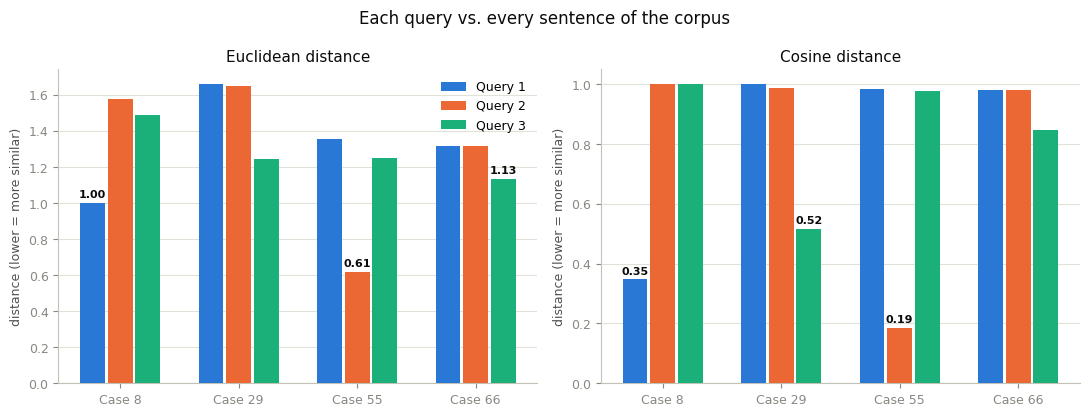

In [12]:
import matplotlib.pyplot as plt

query_colors = ["#2a78d6", "#eb6834", "#1baf7a"]  # fixed order: Query 1, 2, 3

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

n_cases = len(doc_labels)
n_queries = len(query_labels)
group_width = 0.7
bar_width = group_width / n_queries
x = range(n_cases)

for ax, table, title in zip(
    axes, [euclidean_table, cosine_table], ["Euclidean distance", "Cosine distance"]
):
    for qi, (label, color) in enumerate(zip(query_labels, query_colors)):
        offsets = [xi - group_width / 2 + bar_width * (qi + 0.5) for xi in x]
        values = table.loc[label].values
        ax.bar(offsets, values, width=bar_width * 0.9, color=color, label=label, zorder=3)
        best = values.argmin()
        ax.annotate(
            f"{values[best]:.2f}", (offsets[best], values[best]),
            textcoords="offset points", xytext=(0, 4),
            ha="center", fontsize=8, color="#0b0b0b", fontweight="bold"
        )

    ax.set_xticks(list(x))
    ax.set_xticklabels(doc_labels)
    ax.set_ylabel("distance (lower = more similar)", color="#52514e", fontsize=9)
    ax.set_title(title, color="#0b0b0b", fontsize=11)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#c3c2b7")
    ax.tick_params(colors="#898781", labelsize=9)

axes[0].legend(frameon=False, fontsize=9, loc="upper right")
fig.suptitle("Each query vs. every sentence of the corpus", fontsize=12, color="#0b0b0b")
plt.tight_layout()
plt.show()

In [13]:
# The case each query would retrieve, under each metric.
best_matches = pd.DataFrame({
    "query": queries,
    "best match (Euclidean)": euclidean_table.idxmin(axis=1).values,
    "best match (cosine)": cosine_table.idxmin(axis=1).values,
}, index=query_labels)

best_matches

,query,best match (Euclidean),best match (cosine)
Query 1,pulmonary embolism thrombosed,Case 8,Case 8
Query 2,mitral stenosis cerebral,Case 55,Case 55
Query 3,mitral disease bronchitis,Case 66,Case 29


## \#9 Visualizing each query against every sentence of the corpus

The chart below plots, for every query, its distance to each of the four case sentences — one panel per distance metric, so the effect of ignoring vector length (cosine) versus not (Euclidean) is visible side by side. In both panels the **shortest bar marks the best-matching case** for that query.